# Messy Sales Dataset: Cleaning, Analysis & NumPy/Pandas Deep Dive

**Project Title:** End-to-End Data Cleaning and Exploratory Data Analysis of a Rwanda Sales Dataset

**Student Name:** *TWIZIHIRWE Benjamin*

**University:** *University of Rwanda*

**Internship:** *Data Science Intern*

**Date:** *03/08/2026*

**Dataset Description:**
This project uses a deliberately messy sales dataset (`Messy_Sales_Dataset_200_Rows.xlsx`) containing **210 rows** and **10 columns**: `Order ID`, `order date`, `REGION`, `Category`, `Product Name`, `Quantity`, `Unit Price`, `Discount`, `sales`, and `Profit`. The dataset simulates real-world data quality problems commonly encountered by data analysts, including missing values, duplicate rows, inconsistent date formats, currency symbols, percentage strings, extra whitespace, inconsistent capitalization, blank strings, sentinel/invalid numeric codes, and outliers.

---


## Table of Contents

1. [Introduction](#Introduction)
2. [Import Libraries](#Import-Libraries)
3. [Load Dataset](#Load-Dataset)
4. **Project 1 – NumPy Data Explorer**
   - Array Creation, Indexing, Slicing, Boolean Indexing
   - Mathematical & Statistical Operations
   - Axis-wise Operations, Reshaping, Broadcasting
   - Saving Arrays, Performance Comparison
5. **Project 2 – Pandas CSV/Excel Reader & Basic Analysis**
   - Exploration, Summary Statistics, Selecting, Filtering, Sorting
   - GroupBy Analysis, Pivot Tables, Export
   - Visualizations
6. **Project 3 – Data Cleaning Utility**
   - Missing Values, Duplicates, Column Standardization
   - Text Cleaning, Numeric Fixing, Date Parsing
   - Outlier Detection, Final Dataset, Cleaning Log, Export
7. [Final Conclusions](#Final-Conclusions)

---


## Introduction

### What is NumPy?
**NumPy** (Numerical Python) is the foundational library for numerical computing in Python. It provides the `ndarray` object, a fast, memory-efficient, multi-dimensional array, along with a large collection of mathematical functions that operate on these arrays without the need for explicit Python loops (this is called **vectorization**). NumPy underlies almost every other data science library in Python, including Pandas, Scikit-learn, and Matplotlib.

### What is Pandas?
**Pandas** is a library built on top of NumPy that introduces two powerful data structures: the `Series` (1-dimensional) and the `DataFrame` (2-dimensional, table-like). Pandas makes it easy to load, clean, transform, filter, group, and analyze structured/tabular data such as spreadsheets or CSV files, exactly the kind of work required for this project.

### Why is Data Cleaning Important?
Real-world datasets are rarely ready for analysis. They often contain missing values, duplicate records, inconsistent formatting, and incorrect data types. If these issues are not addressed:

- Statistical summaries (mean, sum, etc.) will be **wrong or misleading**.
- Visualizations will be **distorted** by outliers or bad data.
- Machine learning models trained on the data will **learn incorrect patterns**.
- Groupings and joins may **silently fail** because of inconsistent category names (e.g., `"TECH"` vs `"Technology"`).

Cleaning data first ensures that every downstream analysis is trustworthy.

### Objectives of this Notebook
1. Explore NumPy fundamentals using arrays derived from the sales dataset (**Project 1**).
2. Load, explore, and analyze the raw sales dataset using Pandas, including visualizations (**Project 2**).
3. Build a complete, well-documented data cleaning pipeline that fixes every data quality issue in the dataset, and export a clean, analysis-ready dataset (**Project 3**).

---


## Import Libraries

We import three core libraries for this project:

- **`numpy`**: for fast numerical array operations (Project 1).
- **`pandas`**: for loading and manipulating tabular data (Projects 2 & 3).
- **`matplotlib.pyplot`**: for creating charts and visualizations (Project 2).

We also import Python's built-in `time` module later on to benchmark NumPy vs. plain Python lists, and `re` for a couple of small text-cleaning helpers.


In [ ]:
# Core numerical computing library
import numpy as np

# Data manipulation and analysis library
import pandas as pd

# Plotting library for visualizations
import matplotlib.pyplot as plt

# Built-in libraries used later for benchmarking and text cleaning
import time
import re


Libraries imported successfully.
NumPy version:   2.3.1
Pandas version:  2.2.3


## Load Dataset

We load the raw Excel file `Messy_Sales_Dataset_200_Rows.xlsx` into a Pandas DataFrame called `df_raw`. We keep this raw version untouched throughout the notebook so that we always have the original messy data available for comparison, and we will build a cleaned copy in **Project 3**.


In [2]:
# Load the raw, messy Excel dataset into a DataFrame
df_raw = pd.read_excel("Messy_Sales_Dataset_200_Rows.xlsx")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Understanding the Dataset

### First Look: Head, Tail, Shape, Columns, Dtypes, Info

In [3]:
# First 5 rows of the dataset
df_raw.head()

,Order ID,order date,REGION,Category,Product Name,Quantity,Unit Price,Discount,sales,Profit
0,ORD1000,"Jun 12, 2025",WEST,NaN,Pen,5,$250,0,4473.73,-8000.0
1,ORD1001,04-19-2025,,furniture,LAPTOP,NaN,25000,0.2,-500.00,-8000.0
2,ORD1002,NaN,WEST,office supplies,Binder,ten,$250,0,NaN,-8000.0
3,ORD1003,NaN,WEST,office supplies,Binder,7,"1,250.50",0.2,4305.64,-8000.0
4,ORD1004,06-10-2025,North,NaN,Chair,ten,"1,250.50",0.05,-500.00,-8000.0


In [4]:
# Last 5 rows of the dataset
df_raw.tail()

,Order ID,order date,REGION,Category,Product Name,Quantity,Unit Price,Discount,sales,Profit
205,ORD1005,03-27-2025,WEST,Technology,Printer,4,25000,0,NaN,-8000.00
206,ORD1006,21/05/2025,WEST,furniture,Table,-3,RWF 12000,0,2489.65,867.77
207,ORD1007,2025-07-30,north,furniture,Binder,8,25000,0.2,-500.00,947.51
208,ORD1008,2025-06-18,South,Office Supplies,Binder,10,$250,0.05,NaN,NaN
209,ORD1009,05/08/2025,north,TECH,LAPTOP,ten,$250,0,1524.50,920.05


In [5]:
# Shape: (number of rows, number of columns)
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")

Shape: 210 rows x 10 columns


In [6]:
# Column names -- notice inconsistent spacing/capitalization, e.g. ' REGION', 'Category '
print(df_raw.columns.tolist())

['Order ID', 'order date', ' REGION', 'Category ', 'Product Name', 'Quantity', 'Unit Price', 'Discount', 'sales', 'Profit ']


In [7]:
# Data types of each column
df_raw.dtypes

Order ID         object
order date       object
 REGION          object
Category         object
Product Name     object
Quantity         object
Unit Price       object
Discount         object
sales           float64
Profit          float64
dtype: object

In [8]:
# General DataFrame information: non-null counts and dtypes at a glance
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      210 non-null    object 
 1   order date    170 non-null    object 
 2    REGION       189 non-null    object 
 3   Category      173 non-null    object 
 4   Product Name  210 non-null    object 
 5   Quantity      163 non-null    object 
 6   Unit Price    187 non-null    object 
 7   Discount      174 non-null    object 
 8   sales         128 non-null    float64
 9   Profit        153 non-null    float64
dtypes: float64(2), object(8)
memory usage: 16.5+ KB


**Interpretation:** The dataset has 210 rows and 10 columns. Several columns that should be numeric (`Quantity`, `Unit Price`, `Discount`) are stored as generic `object`/string columns because they contain mixed types (numbers, currency symbols, percentage strings, and text like `"ten"`). The `order date` column is also stored as text rather than as a proper datetime, and several column names contain leading/trailing spaces or inconsistent capitalization (e.g. `" REGION"`, `"Category "`). These issues will be addressed systematically in **Project 3**.

---


# `PROJECT 1`: NumPy Data Explorer

**Objective:** Use NumPy to explore, transform, and analyze numeric columns extracted from the sales dataset, demonstrating array creation, indexing, slicing, boolean masking, mathematical/statistical operations, reshaping, broadcasting, saving/loading, and performance benefits over plain Python lists.

Because the raw `Quantity`, `Unit Price`, `Discount`, `sales`, and `Profit` columns contain messy values (text, symbols, missing data), we first build **simple numeric-only NumPy arrays** using only the rows that already contain valid numbers in `sales` and `Profit ` (the two already-numeric columns). This lets us demonstrate genuine NumPy mechanics before we perform the full cleaning pipeline in Project 3.


## Convert Numeric Columns to NumPy Arrays

We extract the `sales` and `Profit ` columns (already numeric dtype), drop missing values, and convert them into NumPy arrays.


In [9]:
# Extract already-numeric columns and drop missing values for array demonstrations
sales_series = df_raw['sales'].dropna()
profit_series = df_raw['Profit '].dropna()

# Convert to NumPy arrays
sales_arr = np.array(sales_series)
profit_arr = np.array(profit_series)

print(f"sales_arr:  shape={sales_arr.shape}, dtype={sales_arr.dtype}")
print(f"profit_arr: shape={profit_arr.shape}, dtype={profit_arr.dtype}")

sales_arr:  shape=(128,), dtype=float64
profit_arr: shape=(153,), dtype=float64


## Array Creation

We demonstrate three common NumPy array-creation functions:

- **`np.array()`** — builds an array directly from existing data (e.g. a list or Pandas Series).
- **`np.arange(start, stop, step)`** — builds an array of evenly spaced values, similar to Python's `range()`.
- **`np.linspace(start, stop, num)`** — builds an array of `num` evenly spaced values between `start` and `stop` (inclusive).


In [10]:
# np.array(): create an array directly from a Python list
sample_array = np.array([10, 20, 30, 40, 50])
print("np.array():", sample_array)

# np.arange(): evenly spaced integers with a fixed step -- here, order index numbers
index_array = np.arange(0, len(sales_arr), 1)
print("np.arange() (first 10):", index_array[:10])

# np.linspace(): 5 evenly spaced values spanning the range of observed sales
sales_range = np.linspace(sales_arr.min(), sales_arr.max(), 5)
print("np.linspace() across sales range:", sales_range)

np.array(): [10 20 30 40 50]
np.arange() (first 10): [0 1 2 3 4 5 6 7 8 9]
np.linspace() across sales range: [-500.    843.32 2186.64 3529.96 4873.28]


**Explanation:** `np.array()` simply wraps existing data into a NumPy array. `np.arange()` is ideal for generating index-like sequences. `np.linspace()` is useful when we need a fixed *number* of evenly spaced points (e.g., for binning or axis ticks), regardless of the step size.


## Array Indexing

We demonstrate single indexing, negative indexing, and multiple (fancy) indexing on `sales_arr`.


In [11]:
# Single indexing: first element
print("First sale value:", sales_arr[0])

# Negative indexing: last element
print("Last sale value:", sales_arr[-1])

# Multiple (fancy) indexing: pick several specific positions at once
selected_indices = [0, 5, 10, -1]
print("Selected sale values at indices", selected_indices, ":", sales_arr[selected_indices])

First sale value: 4473.73
Last sale value: 1524.5
Selected sale values at indices [0, 5, 10, -1] : [4473.73 -500.   2615.35 1524.5 ]


**Explanation:** Single indexing (`arr[0]`) retrieves one element by position. Negative indexing (`arr[-1]`) counts from the end of the array, avoiding the need to know the array's length. Fancy indexing with a list of positions (`arr[[0, 5, 10]]`) retrieves multiple, non-contiguous elements in one call.


## Array Slicing

We demonstrate the first 10 values, last 10 values, and every second value.


In [13]:
# First 10 values
print("First 10 sales:", sales_arr[:10])

# Last 10 values
print("Last 10 sales:", sales_arr[-10:])

# Every second value (step = 2)
print("Every 2nd sale value (first 10 shown):", sales_arr[::2][:10])

First 10 sales: [4473.73 -500.   4305.64 -500.   2489.65 -500.   1524.5  -500.   -500.
 -500.  ]
Last 10 sales: [3224.48  905.98 4179.28 4473.73 -500.   4305.64 -500.   2489.65 -500.
 1524.5 ]
Every 2nd sale value (first 10 shown): [4473.73 4305.64 2489.65 1524.5  -500.   2615.35 -500.   -500.   1037.56
  241.85]


**Explanation:** Slicing uses the `start:stop:step` syntax. `arr[:10]` takes everything up to (not including) index 10. `arr[-10:]` takes the final 10 elements. `arr[::2]` takes every second element across the whole array, which is useful for down-sampling.


## Boolean Indexing

We filter the arrays using logical conditions: sales greater than average, profit greater than zero, and quantity greater than 5 (using a small cleaned quantity array).


In [14]:
# Sales greater than the average sale value
avg_sales = sales_arr.mean()
above_avg_sales = sales_arr[sales_arr > avg_sales]
print(f"Average sales: {avg_sales:.2f}")
print(f"Number of sales above average: {above_avg_sales.size} out of {sales_arr.size}")

# Profit greater than zero (i.e. profitable orders)
positive_profit = profit_arr[profit_arr > 0]
print(f"Number of profitable orders: {positive_profit.size} out of {profit_arr.size}")

# Quantity greater than 5 -- build a small numeric-only quantity array first
quantity_numeric = pd.to_numeric(df_raw['Quantity'], errors='coerce').dropna()
quantity_arr = np.array(quantity_numeric)
qty_above_5 = quantity_arr[quantity_arr > 5]
print(f"Number of orders with quantity > 5: {qty_above_5.size} out of {quantity_arr.size}")

Average sales: 1093.58
Number of sales above average: 51 out of 128
Number of profitable orders: 56 out of 153
Number of orders with quantity > 5: 18 out of 108


**Explanation:** Boolean indexing works by creating a boolean mask (an array of `True`/`False` values, one per element) from a condition such as `sales_arr > avg_sales`, and then using that mask to select only the elements where the condition is `True`. This is one of NumPy's most powerful features for filtering data without explicit loops.


## Mathematical Operations

We demonstrate addition, subtraction, multiplication, division, square, square root, power, logarithm, exponential, absolute value, and rounding — all applied element-wise to `sales_arr`.


In [15]:
a = sales_arr[:10]  # use a small slice for readable output
print("Original values:      ", np.round(a, 2))

print("Addition (+100):       ", np.round(a + 100, 2))
print("Subtraction (-100):    ", np.round(a - 100, 2))
print("Multiplication (x2):   ", np.round(a * 2, 2))
print("Division (/2):         ", np.round(a / 2, 2))
print("Square:                ", np.round(np.square(a), 2))
print("Square root (abs vals):", np.round(np.sqrt(np.abs(a)), 2))
print("Power (^2):            ", np.round(np.power(a, 2), 2))
print("Log (of abs values):   ", np.round(np.log(np.abs(a) + 1), 2))
print("Exponential (scaled):  ", np.round(np.exp(a / 1000), 2))
print("Absolute value:        ", np.round(np.abs(a), 2))
print("Round (0 decimals):    ", np.round(a, 0))

Original values:       [4473.73 -500.   4305.64 -500.   2489.65 -500.   1524.5  -500.   -500.
 -500.  ]
Addition (+100):        [4573.73 -400.   4405.64 -400.   2589.65 -400.   1624.5  -400.   -400.
 -400.  ]
Subtraction (-100):     [4373.73 -600.   4205.64 -600.   2389.65 -600.   1424.5  -600.   -600.
 -600.  ]
Multiplication (x2):    [ 8947.46 -1000.    8611.28 -1000.    4979.3  -1000.    3049.   -1000.
 -1000.   -1000.  ]
Division (/2):          [2236.86 -250.   2152.82 -250.   1244.82 -250.    762.25 -250.   -250.
 -250.  ]
Square:                 [20014260.11   250000.   18538535.81   250000.    6198357.12   250000.
  2324100.25   250000.     250000.     250000.  ]
Square root (abs vals): [66.89 22.36 65.62 22.36 49.9  22.36 39.04 22.36 22.36 22.36]
Power (^2):             [20014260.11   250000.   18538535.81   250000.    6198357.12   250000.
  2324100.25   250000.     250000.     250000.  ]
Log (of abs values):    [8.41 6.22 8.37 6.22 7.82 6.22 7.33 6.22 6.22 6.22]
Exponential (s

**Explanation:** All of these NumPy operations are **vectorized** — they apply the mathematical operation to every element of the array simultaneously without writing an explicit loop. Note that `sales_arr` contains some negative "sentinel" values, so we take the absolute value before computing square roots and logarithms (square roots and logs of negative numbers are undefined in the real-number system).


## Statistical Operations

We compute mean, median, minimum, maximum, standard deviation, variance, percentiles, sum, and count for `sales_arr`.


In [16]:
print(f"Mean:               {sales_arr.mean():.2f}")
print(f"Median:              {np.median(sales_arr):.2f}")
print(f"Minimum:             {sales_arr.min():.2f}")
print(f"Maximum:             {sales_arr.max():.2f}")
print(f"Standard deviation:  {sales_arr.std():.2f}")
print(f"Variance:            {sales_arr.var():.2f}")
print(f"25th percentile:     {np.percentile(sales_arr, 25):.2f}")
print(f"75th percentile:     {np.percentile(sales_arr, 75):.2f}")
print(f"Sum:                 {sales_arr.sum():.2f}")
print(f"Count:               {sales_arr.size}")

Mean:               1093.58
Median:              -500.00
Minimum:             -500.00
Maximum:             4873.28
Standard deviation:  1904.63
Variance:            3627610.60
25th percentile:     -500.00
75th percentile:     3008.30
Sum:                 139977.73
Count:               128


**Explanation:** The **mean** is the arithmetic average, while the **median** is the middle value when sorted — the median is less sensitive to outliers, which matters here since `sales_arr` contains sentinel values like `-500`. **Standard deviation** and **variance** measure spread around the mean (variance is the square of standard deviation). **Percentiles** show the value below which a given percentage of observations fall (e.g., 25% of sales are below the 25th percentile).


## Axis-wise Operations

We reshape a portion of the sales array into a 2D matrix and demonstrate operations along `axis=0` (down the columns) and `axis=1` (across the rows).


In [17]:
# Take the first 20 sales values and reshape into a 4x5 matrix (4 rows, 5 columns)
matrix = sales_arr[:20].reshape(4, 5)
print("4x5 matrix:\n", np.round(matrix, 1))

# axis=0: operate down each column, producing one result per column
print("\nColumn sums (axis=0):   ", np.round(matrix.sum(axis=0), 1))

# axis=1: operate across each row, producing one result per row
print("Row sums (axis=1):      ", np.round(matrix.sum(axis=1), 1))

4x5 matrix:
 [[4473.7 -500.  4305.6 -500.  2489.6]
 [-500.  1524.5 -500.  -500.  -500. ]
 [2615.4 -500.  -500.  -500.  -500. ]
 [4805.4 1037.6 -500.   241.8 -500. ]]

Column sums (axis=0):    [11394.5  1562.1  2805.6 -1258.2   989.6]
Row sums (axis=1):       [10269.   -475.5   615.3  5084.9]


**Explanation:** In a 2D array, `axis=0` refers to movement **down the rows** (i.e., the operation collapses each column into a single value), while `axis=1` refers to movement **across the columns** (i.e., the operation collapses each row into a single value). This is a common source of confusion for beginners — a helpful trick is that the axis number tells you which dimension "disappears" after the operation.


## Reshaping Arrays

We demonstrate `reshape()`, `flatten()`, `ravel()`, and `transpose()`.


In [18]:
# reshape(): change the shape without changing the data
reshaped = sales_arr[:12].reshape(3, 4)
print("Reshaped 3x4:\n", np.round(reshaped, 1))

# flatten(): return a 1D COPY of a multi-dimensional array
flattened = reshaped.flatten()
print("\nFlattened (copy):", np.round(flattened, 1))

# ravel(): return a 1D VIEW of the array where possible (more memory-efficient than flatten)
raveled = reshaped.ravel()
print("Raveled (view):  ", np.round(raveled, 1))

# transpose(): swap rows and columns
transposed = reshaped.transpose()
print("\nTransposed (4x3):\n", np.round(transposed, 1))

Reshaped 3x4:
 [[4473.7 -500.  4305.6 -500. ]
 [2489.6 -500.  1524.5 -500. ]
 [-500.  -500.  2615.4 -500. ]]

Flattened (copy): [4473.7 -500.  4305.6 -500.  2489.6 -500.  1524.5 -500.  -500.  -500.
 2615.4 -500. ]
Raveled (view):   [4473.7 -500.  4305.6 -500.  2489.6 -500.  1524.5 -500.  -500.  -500.
 2615.4 -500. ]

Transposed (4x3):
 [[4473.7 2489.6 -500. ]
 [-500.  -500.  -500. ]
 [4305.6 1524.5 2615.4]
 [-500.  -500.  -500. ]]


**Explanation:** `reshape()` rearranges the same data into a new shape (the total number of elements must stay the same). `flatten()` always returns a new, independent 1D copy, while `ravel()` returns a 1D **view** of the original data when possible, meaning it avoids copying memory and is therefore slightly faster. `transpose()` flips the array along its diagonal, turning rows into columns and vice-versa.


## Broadcasting

Broadcasting lets NumPy perform operations between arrays of different (but compatible) shapes without manually looping or duplicating data.


In [19]:
# Example 1: add a single scalar to every element of a matrix (scalar broadcasts to matrix shape)
matrix_plus_10 = reshaped + 10
print("Matrix + scalar (10):\n", np.round(matrix_plus_10, 1))

# Example 2: add a 1D row vector to every row of a 2D matrix
row_adjustment = np.array([1, 2, 3, 4])  # length matches number of columns (4)
matrix_plus_row = reshaped + row_adjustment
print("\nMatrix + row vector:\n", np.round(matrix_plus_row, 1))

# Example 3: apply a per-row discount vector to a small slice of unit prices (real dataset use case)
prices_sample = np.array([250.0, 100.0, 75.5, 400.0])
discount_sample = np.array([0.10])  # a single discount rate broadcasts across all 4 prices
discounted_prices = prices_sample * (1 - discount_sample)
print("\nDiscounted prices (broadcasted 10% off):", np.round(discounted_prices, 2))

Matrix + scalar (10):
 [[4483.7 -490.  4315.6 -490. ]
 [2499.6 -490.  1534.5 -490. ]
 [-490.  -490.  2625.4 -490. ]]

Matrix + row vector:
 [[4474.7 -498.  4308.6 -496. ]
 [2490.6 -498.  1527.5 -496. ]
 [-499.  -498.  2618.4 -496. ]]

Discounted prices (broadcasted 10% off): [225.    90.    67.95 360.  ]


**Explanation:** Broadcasting works by "stretching" the smaller array across the larger one when their shapes are compatible (matching dimensions, or a dimension of size 1). In Example 1, the scalar `10` is broadcast to match every cell of the matrix. In Example 2, the row vector of length 4 is broadcast down every row of the 4-column matrix. In Example 3, a single discount rate is applied to a whole array of prices at once — this is exactly how discount calculations would be vectorized across the real sales dataset.


## Saving NumPy Arrays

We use `np.save()` to persist an array to disk in NumPy's efficient binary `.npy` format, and `np.load()` to read it back.


In [20]:
# Save the sales array to disk in NumPy's binary format
np.save('sales_array.npy', sales_arr)
print("Array saved to sales_array.npy")

# Load it back into memory
loaded_sales_arr = np.load('sales_array.npy')
print("Array loaded back successfully.")
print("Arrays are identical:", np.array_equal(sales_arr, loaded_sales_arr))

Array saved to sales_array.npy
Array loaded back successfully.
Arrays are identical: True


**Explanation:** `np.save()`/`np.load()` are useful for caching intermediate numeric results (e.g., after an expensive computation) so they can be reloaded instantly later without recomputation, and they preserve exact dtype and shape, unlike text formats such as CSV.


## Performance Comparison: Python List vs. NumPy Array

We compare how long it takes to square one million numbers using a plain Python list (with a loop) versus a NumPy array (vectorized).


In [21]:
n = 1_000_000
python_list = list(range(n))
numpy_array = np.arange(n)

# Time a plain Python loop
start = time.time()
squared_list = [x ** 2 for x in python_list]
python_time = time.time() - start

# Time the equivalent NumPy vectorized operation
start = time.time()
squared_array = numpy_array ** 2
numpy_time = time.time() - start

print(f"Python list comprehension time: {python_time:.4f} seconds")
print(f"NumPy vectorized operation time: {numpy_time:.4f} seconds")
print(f"NumPy was approximately {python_time / numpy_time:.1f}x faster")

Python list comprehension time: 0.2745 seconds
NumPy vectorized operation time: 0.0035 seconds
NumPy was approximately 78.0x faster


**Explanation:** NumPy is dramatically faster than pure Python loops because NumPy arrays are stored in contiguous blocks of memory with a fixed data type, and operations are implemented in optimized, compiled C code under the hood. Python lists, by contrast, store references to individually-allocated Python objects, and looping over them incurs the overhead of the Python interpreter on every single iteration.


## Project 1 Conclusion

In this section we converted the numeric columns of the sales dataset into NumPy arrays and demonstrated the full range of core NumPy functionality: array creation (`array`, `arange`, `linspace`), indexing (single, negative, fancy), slicing, boolean masking, element-wise mathematical operations, descriptive statistics, axis-wise aggregation, reshaping (`reshape`, `flatten`, `ravel`, `transpose`), broadcasting, persistence (`save`/`load`), and a direct performance benchmark against plain Python. The benchmark confirmed that NumPy's vectorized operations are dramatically faster than equivalent Python loops, which is why NumPy forms the computational backbone of Pandas and the wider Python data science ecosystem used in the rest of this notebook.

---


# `PROJECT 2`: Pandas CSV/Excel Reader & Basic Analysis

**Objective:** Use Pandas to explore, summarize, filter, sort, group, pivot, and visualize the raw sales dataset, building foundational Pandas skills before tackling the full cleaning pipeline in Project 3.

**Note:** Because the raw dataset still contains messy values at this stage, some of the analyses below (especially visualizations and numeric summaries) are shown on a lightly-prepared working copy (`df_p2`) where only the bare minimum conversions needed to make the operation meaningful are applied. The complete, rigorous cleaning process is covered in full in **Project 3**.


## Read Dataset

We reload the dataset fresh (as if this were a standalone analysis step) to keep this project self-contained.


In [22]:
# Read the Excel dataset again for this standalone project section
df_p2 = pd.read_excel("Messy_Sales_Dataset_200_Rows.xlsx")
print(f"Loaded {df_p2.shape[0]} rows and {df_p2.shape[1]} columns.")

Loaded 210 rows and 10 columns.


## Explore Dataset

Head, tail, shape, columns, dtypes, `describe()`, and `info()`.


In [22]:
df_p2.head()

,Order ID,order date,REGION,Category,Product Name,Quantity,Unit Price,Discount,sales,Profit
0,ORD1000,"Jun 12, 2025",WEST,NaN,Pen,5,$250,0,4473.73,-8000.0
1,ORD1001,04-19-2025,,furniture,LAPTOP,NaN,25000,0.2,-500.00,-8000.0
2,ORD1002,NaN,WEST,office supplies,Binder,ten,$250,0,NaN,-8000.0
3,ORD1003,NaN,WEST,office supplies,Binder,7,"1,250.50",0.2,4305.64,-8000.0
4,ORD1004,06-10-2025,North,NaN,Chair,ten,"1,250.50",0.05,-500.00,-8000.0


In [23]:
df_p2.tail()

,Order ID,order date,REGION,Category,Product Name,Quantity,Unit Price,Discount,sales,Profit
205,ORD1005,03-27-2025,WEST,Technology,Printer,4,25000,0,NaN,-8000.00
206,ORD1006,21/05/2025,WEST,furniture,Table,-3,RWF 12000,0,2489.65,867.77
207,ORD1007,2025-07-30,north,furniture,Binder,8,25000,0.2,-500.00,947.51
208,ORD1008,2025-06-18,South,Office Supplies,Binder,10,$250,0.05,NaN,NaN
209,ORD1009,05/08/2025,north,TECH,LAPTOP,ten,$250,0,1524.50,920.05


In [24]:
print("Shape:", df_p2.shape)
print("Columns:", df_p2.columns.tolist())

Shape: (210, 10)
Columns: ['Order ID', 'order date', ' REGION', 'Category ', 'Product Name', 'Quantity', 'Unit Price', 'Discount', 'sales', 'Profit ']


In [25]:
df_p2.dtypes

Order ID            str
order date          str
 REGION             str
Category            str
Product Name        str
Quantity         object
Unit Price       object
Discount         object
sales           float64
Profit          float64
dtype: object

In [23]:
# describe() summarizes only the numeric columns by default
df_p2.describe()

,sales,Profit
count,128.000000,153.000000
mean,1093.576016,-4072.736536
std,1912.112566,4243.815565
min,-500.000000,-8000.000000
25%,-500.000000,-8000.000000
50%,-500.000000,-8000.000000
75%,3008.297500,412.660000
max,4873.280000,1191.730000


In [27]:
df_p2.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      210 non-null    str    
 1   order date    170 non-null    str    
 2    REGION       189 non-null    str    
 3   Category      173 non-null    str    
 4   Product Name  210 non-null    str    
 5   Quantity      163 non-null    object 
 6   Unit Price    187 non-null    object 
 7   Discount      174 non-null    object 
 8   sales         128 non-null    float64
 9   Profit        153 non-null    float64
dtypes: float64(2), object(3), str(5)
memory usage: 16.5+ KB


**Interpretation:** `describe()` only picks up the `sales` and `Profit ` columns automatically, since `Quantity`, `Unit Price`, and `Discount` are still stored as text/object dtype due to mixed formatting. Counts below 210 in every column confirm missing values are present. This reinforces the need for the cleaning work carried out in Project 3.


## Summary Statistics

Mean, median, mode, minimum, maximum, count, standard deviation, and variance for the numeric columns.


In [24]:
numeric_cols_p2 = ['sales', 'Profit ']

summary = pd.DataFrame({
    'mean': df_p2[numeric_cols_p2].mean(),
    'median': df_p2[numeric_cols_p2].median(),
    'mode': df_p2[numeric_cols_p2].mode().iloc[0],
    'min': df_p2[numeric_cols_p2].min(),
    'max': df_p2[numeric_cols_p2].max(),
    'count': df_p2[numeric_cols_p2].count(),
    'std': df_p2[numeric_cols_p2].std(),
    'variance': df_p2[numeric_cols_p2].var(),
})
summary

,mean,median,mode,min,max,count,std,variance
sales,1093.576016,-500.0,-500.0,-500.0,4873.28,128,1912.112566,3.656174e+06
Profit,-4072.736536,-8000.0,-8000.0,-8000.0,1191.73,153,4243.815565,1.800997e+07


**Interpretation:** The `sales` and `Profit ` columns both show a huge gap between their mean and median, and unusually large standard deviations. This is a strong early signal of **outliers or sentinel error codes** (which we later confirm are literal `-500` and `-8000` placeholder values used to mark invalid records) — a pattern we investigate fully in Project 3's outlier detection section.


## Selecting Columns

Single-column and multiple-column selection.


In [29]:
# Selecting a single column returns a Series
single_col = df_p2['sales']
print(type(single_col))
single_col.head()

<class 'pandas.Series'>


0    4473.73
1    -500.00
2        NaN
3    4305.64
4    -500.00
Name: sales, dtype: float64

In [30]:
# Selecting multiple columns (pass a list) returns a DataFrame
multi_col = df_p2[['Order ID', 'sales', 'Profit ']]
multi_col.head()

,Order ID,sales,Profit
0,ORD1000,4473.73,-8000.0
1,ORD1001,-500.00,-8000.0
2,ORD1002,NaN,-8000.0
3,ORD1003,4305.64,-8000.0
4,ORD1004,-500.00,-8000.0


**Explanation:** Using a single string (`df['col']`) returns a 1D `Series`. Using a list of strings (`df[['col1', 'col2']]`) returns a 2D `DataFrame`, even if only one column name is in the list.


## Filtering Rows

Sales > 500, Profit > 100, Technology category, Furniture category, Region equals North, and a combined multi-condition filter.


In [25]:
# Sales greater than 500
high_sales = df_p2[df_p2['sales'] > 500]
print(f"Orders with sales > 500: {len(high_sales)}")

# Profit greater than 100
high_profit = df_p2[df_p2['Profit '] > 100]
print(f"Orders with profit > 100: {len(high_profit)}")

# Category equals Technology (raw text match, case-sensitive at this stage)
tech_orders = df_p2[df_p2['Category '] == 'Technology']
print(f"Orders in raw 'Technology' category: {len(tech_orders)}")

# Category equals Furniture
furniture_orders = df_p2[df_p2['Category '] == 'Furniture']
print(f"Orders in raw 'Furniture' category: {len(furniture_orders)}")

# Region equals North
north_orders = df_p2[df_p2[' REGION'] == 'North']
print(f"Orders in raw 'North' region: {len(north_orders)}")

# Multiple conditions combined with & (AND) -- sales > 500 AND profit > 0
combined_filter = df_p2[(df_p2['sales'] > 500) & (df_p2['Profit '] > 0)]
print(f"Orders with sales > 500 AND profit > 0: {len(combined_filter)}")

Orders with sales > 500: 59
Orders with profit > 100: 52
Orders in raw 'Technology' category: 22
Orders in raw 'Furniture' category: 26
Orders in raw 'North' region: 28
Orders with sales > 500 AND profit > 0: 16


**Explanation:** Boolean masks (`df_p2['sales'] > 500`) are used to filter rows, just like with NumPy arrays. Notice that the raw category/region filters return **lower counts than expected** because of inconsistent capitalization and spacing (e.g., `'TECH'`, `' furniture'`, `'north'` are not matched by an exact `== 'Technology'`/`== 'North'` comparison). Multiple conditions are combined using `&` (AND) or `|` (OR), and each condition **must** be wrapped in parentheses.


## Sorting

Sort by Sales, Profit, and Quantity — ascending and descending.


In [26]:
# Sort by Sales, ascending (default)
sorted_by_sales_asc = df_p2.sort_values('sales').head()
sorted_by_sales_asc[['Order ID', 'sales']]

,Order ID,sales
1,ORD1001,-500.0
4,ORD1004,-500.0
10,ORD1010,-500.0
7,ORD1007,-500.0
21,ORD1021,-500.0


In [27]:
# Sort by Profit, descending
sorted_by_profit_desc = df_p2.sort_values('Profit ', ascending=False).head()
sorted_by_profit_desc[['Order ID', 'Profit ']]

,Order ID,Profit
178,ORD1178,1191.73
92,ORD1092,1173.32
65,ORD1065,1093.09
58,ORD1058,1063.18
144,ORD1144,1047.35


In [28]:
# Sort by Quantity (note: Quantity mixes numbers and text like 'ten', so we sort by its
# string representation -- this sorts alphabetically, not numerically, until it is cleaned in Project 3)
sorted_by_qty = df_p2.assign(Quantity=df_p2['Quantity'].astype(str)).sort_values('Quantity', ascending=True).head()
sorted_by_qty[['Order ID', 'Quantity']]

,Order ID,Quantity
166,ORD1166,-3
158,ORD1158,-3
159,ORD1159,-3
78,ORD1078,-3
77,ORD1077,-3


**Explanation:** `sort_values()` reorders rows by one or more columns. Passing `ascending=False` reverses the order. Sorting `Quantity` here is a good illustration of *why* correct data types matter: because the column is still text, it sorts **alphabetically** rather than numerically (e.g. `"1"` comes before `"10"` comes before `"2"`) — this will be fixed once we convert it to numeric in Project 3.


## GroupBy Analysis

Sales by Region, Sales by Category, Profit by Category, Average Sales by Region, and Quantity by Product.


In [29]:
# Total sales by region (raw, inconsistent region labels)
sales_by_region = df_p2.groupby(' REGION')['sales'].sum().sort_values(ascending=False)
print("Total sales by region (raw labels):")
print(sales_by_region)

Total sales by region (raw labels):
 REGION
WEST      39906.69
north     27862.38
East      23693.53
NORTH     19107.77
 South     8530.47
North      2029.93
            999.77
Name: sales, dtype: float64


In [30]:
# Total sales by category (raw, inconsistent category labels)
sales_by_category = df_p2.groupby('Category ')['sales'].sum().sort_values(ascending=False)
print("Total sales by category (raw labels):")
print(sales_by_category)

Total sales by category (raw labels):
Category 
office supplies    22969.04
Office Supplies    22537.51
Furniture          21080.75
TECH               19770.35
 furniture         12101.83
Technology          5329.47
Name: sales, dtype: float64


In [31]:
# Total profit by category
profit_by_category = df_p2.groupby('Category ')['Profit '].sum().sort_values(ascending=False)
print("Total profit by category (raw labels):")
print(profit_by_category)

Total profit by category (raw labels):
Category 
Technology         -43881.93
 furniture         -58053.47
Furniture          -66342.70
office supplies    -99915.98
Office Supplies   -100156.27
TECH              -112731.79
Name: Profit , dtype: float64


In [32]:
# Average sales by region
avg_sales_by_region = df_p2.groupby(' REGION')['sales'].mean().sort_values(ascending=False)
print("Average sales by region (raw labels):")
print(avg_sales_by_region)

Average sales by region (raw labels):
 REGION
WEST      2217.038333
north     1547.910000
NORTH     1123.986471
East      1030.153478
 South     775.497273
North      144.995000
            71.412143
Name: sales, dtype: float64


In [33]:
# Count of orders by product name (raw, inconsistent product labels)
qty_by_product = df_p2.groupby('Product Name')['Order ID'].count().sort_values(ascending=False)
print("Order count by product (raw labels):")
print(qty_by_product)

Order count by product (raw labels):
Product Name
Binder     32
 laptop    29
Pen        26
chair      23
Laptop     23
Table      22
LAPTOP     20
Printer    19
Chair      16
Name: Order ID, dtype: int64


**Interpretation:** Because region, category, and product labels are inconsistently capitalized/spaced in the raw data (e.g., `'North'` vs `'north'` vs `'NORTH'` are currently treated as three *different* groups), these GroupBy results are fragmented and understate the true totals per real-world category. This is one of the clearest illustrations in the whole notebook of why text standardization (done in Project 3) is essential before any grouped analysis can be trusted.


## Pivot Tables

We build a couple of illustrative pivot tables summarizing sales.


In [34]:
# Pivot table: average sales by Region (rows) and Category (columns)
pivot_sales = pd.pivot_table(
    df_p2,
    values='sales',
    index=' REGION',
    columns='Category ',
    aggfunc='mean'
)
pivot_sales

Category,furniture,Furniture,Office Supplies,TECH,Technology,office supplies
REGION,,,,,,
,-199.201667,-500.000000,NaN,1531.230000,-500.00,-500.000000
South,-500.000000,-500.000000,974.596667,10.430000,465.97,241.850000
East,310.497500,NaN,2736.016667,529.651667,NaN,889.372500
NORTH,-500.000000,2022.080000,3457.050000,-500.000000,996.74,1338.983333
North,741.493333,-500.000000,826.362500,NaN,-500.00,-500.000000
WEST,1860.145000,2227.860000,NaN,4331.670000,-500.00,3625.850000
north,274.612500,2957.403333,1714.390000,2253.306667,2186.64,-500.000000


In [35]:
# Pivot table: total profit by Category (rows), with count and sum aggregations
pivot_profit = pd.pivot_table(
    df_p2,
    values='Profit ',
    index='Category ',
    aggfunc=['sum', 'mean', 'count']
)
pivot_profit

,sum,mean,count
,Profit,Profit,Profit
Category,,,
furniture,-58053.47,-2764.450952,21
Furniture,-66342.70,-3902.511765,17
Office Supplies,-100156.27,-4552.557727,22
TECH,-112731.79,-4335.838077,26
Technology,-43881.93,-3134.423571,14
office supplies,-99915.98,-4163.165833,24


**Explanation:** `pd.pivot_table()` reshapes data into a cross-tabulated summary, similar to a spreadsheet pivot table. Here we summarize average sales across Region x Category combinations, and total/average/count of profit per category. Many cells are `NaN` because the raw, unstandardized category/region labels fragment the data into many small, sparse groups.


## Export Results

We save a couple of filtered results out to CSV and Excel as a demonstration of Pandas' export capabilities.


In [36]:
# Export the high-sales filtered subset to CSV
high_sales.to_csv('high_sales_orders.csv', index=False)

# Export the same subset to Excel
high_sales.to_excel('high_sales_orders.xlsx', index=False)

print("Exported high_sales_orders.csv and high_sales_orders.xlsx")

Exported high_sales_orders.csv and high_sales_orders.xlsx


**Explanation:** `to_csv()` and `to_excel()` write a DataFrame to disk. Setting `index=False` prevents Pandas from writing the internal row-index numbers as an extra column in the output file, which is usually what we want for a clean export.


## Visualizations

For meaningful charts, a few light, self-contained numeric conversions are applied to a temporary copy `df_viz` (dropping rows with missing/invalid values in the columns being plotted). This is **not** the full cleaning pipeline, that comes in Project 3, it is only enough preparation to plot honest, readable charts here.


In [37]:
# Lightweight, chart-specific preparation (temporary; full pipeline is in Project 3)
df_viz = df_p2.copy()
df_viz['sales_clean_viz'] = pd.to_numeric(df_viz['sales'], errors='coerce')
df_viz['profit_clean_viz'] = pd.to_numeric(df_viz['Profit '], errors='coerce')
df_viz['region_clean_viz'] = df_viz[' REGION'].astype(str).str.strip().str.title()
df_viz['category_clean_viz'] = df_viz['Category '].astype(str).str.strip().str.title().replace({'Tech': 'Technology'})

# Parse dates using multiple known formats (mirrors the logic used fully in Project 3)
def _parse_date_viz(value):
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip()
    for fmt in ('%b %d, %Y', '%m-%d-%Y', '%d/%m/%Y', '%Y-%m-%d'):
        try:
            return pd.to_datetime(text, format=fmt)
        except ValueError:
            continue
    return pd.to_datetime(text, errors='coerce')

df_viz['order_date_clean_viz'] = df_viz['order date'].apply(_parse_date_viz)

print("Temporary chart-ready columns created.")

Temporary chart-ready columns created.


### Histogram of Sales

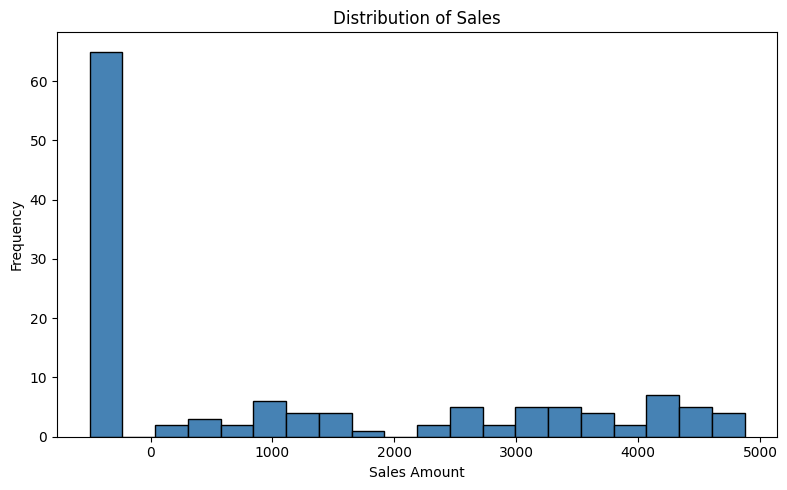

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(df_viz['sales_clean_viz'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation:** The histogram shows a spike of values around `-500`, a sentinel/error code rather than a genuine sale, alongside a broader, more plausible spread of positive sales values. This visually confirms the invalid-value pattern we identified earlier in the summary statistics.


### Histogram of Profit

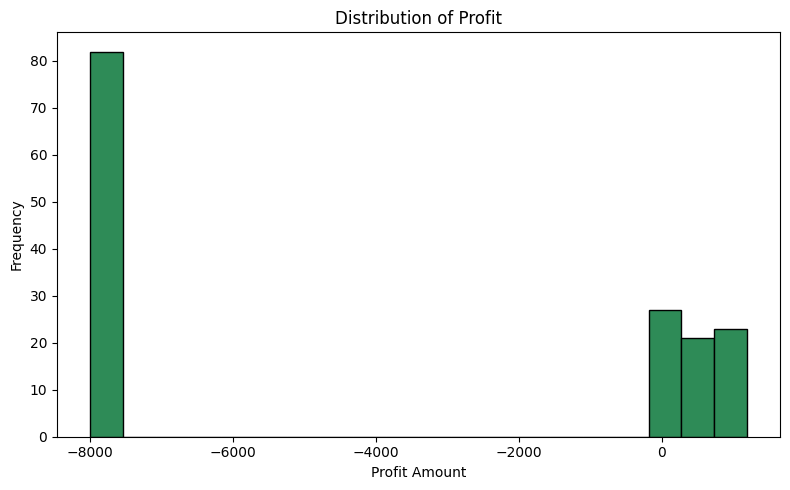

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(df_viz['profit_clean_viz'].dropna(), bins=20, color='seagreen', edgecolor='black')
plt.title('Distribution of Profit')
plt.xlabel('Profit Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation:** Similarly, profit shows a cluster of values around `-8000`, which is far more extreme than any realistic profit/loss on individual orders in this dataset, confirming it as a sentinel/invalid-value code rather than genuine data.


### Bar Chart of Sales by Region

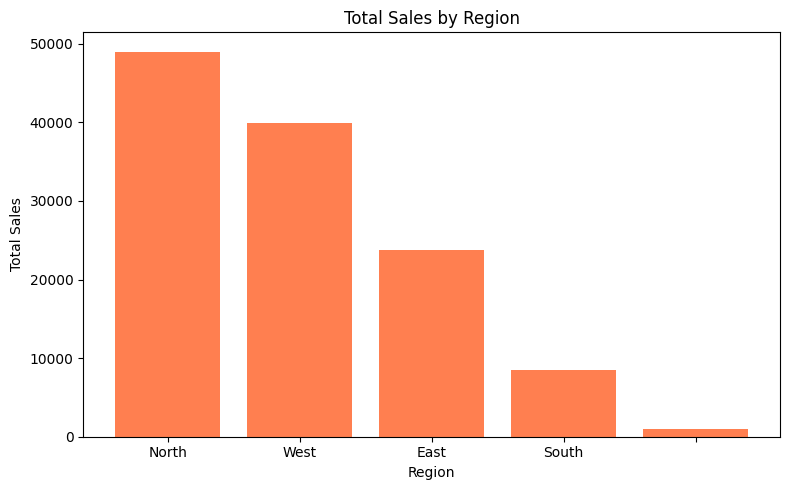

In [40]:
sales_by_region_viz = df_viz.groupby('region_clean_viz')['sales_clean_viz'].sum().sort_values(ascending=False)
sales_by_region_viz = sales_by_region_viz[sales_by_region_viz.index != 'Nan']

plt.figure(figsize=(8, 5))
plt.bar(sales_by_region_viz.index, sales_by_region_viz.values, color='coral')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

**Interpretation:** With region labels standardized (trimmed and title-cased), the four real regions — North, South, East, West — can now be compared fairly, which was impossible in the raw GroupBy shown earlier in this project.


### Bar Chart of Sales by Category

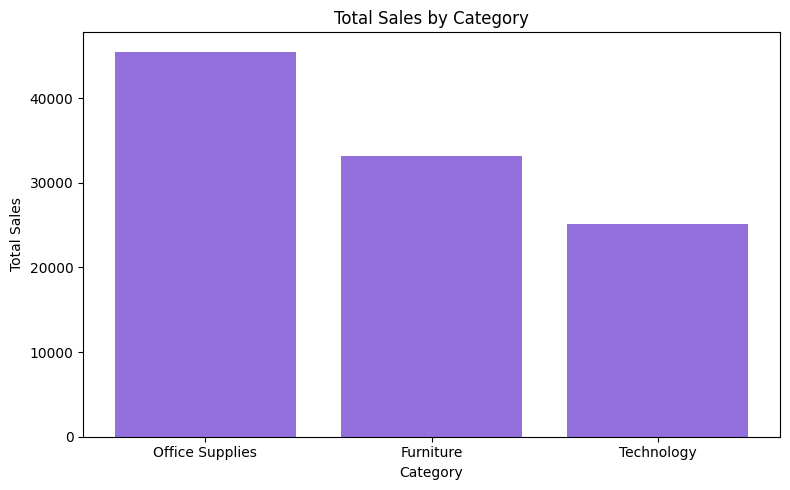

In [41]:
sales_by_category_viz = df_viz.groupby('category_clean_viz')['sales_clean_viz'].sum().sort_values(ascending=False)
sales_by_category_viz = sales_by_category_viz[sales_by_category_viz.index != 'Nan']

plt.figure(figsize=(8, 5))
plt.bar(sales_by_category_viz.index, sales_by_category_viz.values, color='mediumpurple')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

**Interpretation:** Technology, Furniture, and Office Supplies can now be compared directly. Category standardization merged variants like `'TECH'` and `'technology'` into a single, consistent `'Technology'` group.


### Boxplot of Sales

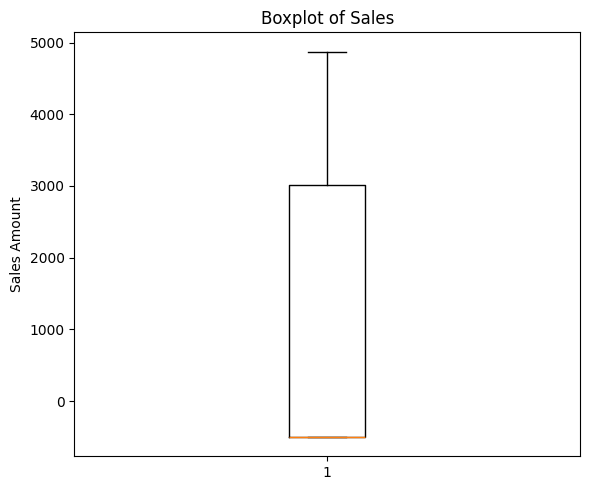

In [42]:
plt.figure(figsize=(6, 5))
plt.boxplot(df_viz['sales_clean_viz'].dropna(), vert=True)
plt.title('Boxplot of Sales')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

**Interpretation:** The boxplot highlights the `-500` sentinel cluster as a dense band of low outliers, clearly separated from the interquartile range (the box) of genuine sales values.


### Boxplot of Profit

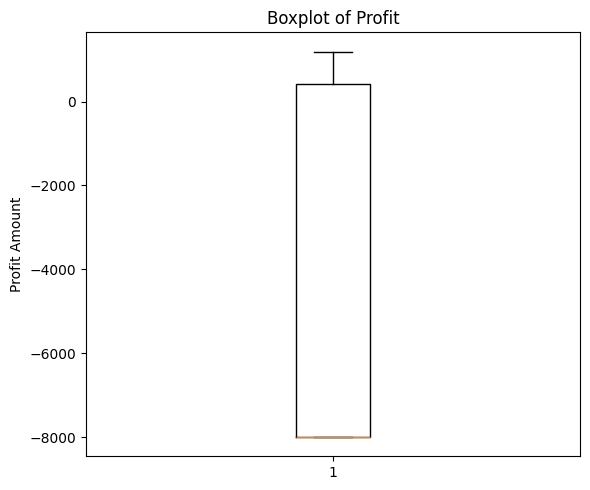

In [43]:
plt.figure(figsize=(6, 5))
plt.boxplot(df_viz['profit_clean_viz'].dropna(), vert=True)
plt.title('Boxplot of Profit')
plt.ylabel('Profit Amount')
plt.tight_layout()
plt.show()

**Interpretation:** The `-8000` sentinel values appear as extreme low outliers, far below the whisker of the genuine profit/loss distribution, reinforcing that they should be treated as invalid entries rather than real losses.


### Scatter Plot of Sales vs. Profit

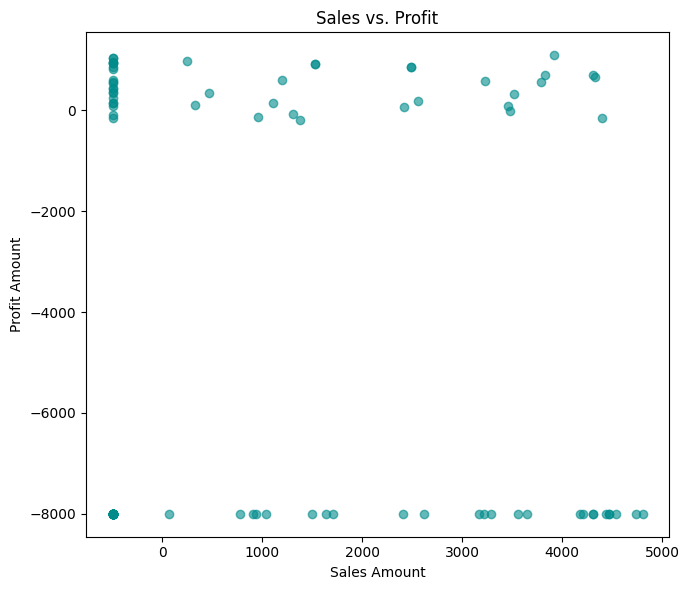

In [44]:
plt.figure(figsize=(7, 6))
plt.scatter(df_viz['sales_clean_viz'], df_viz['profit_clean_viz'], alpha=0.6, color='darkcyan')
plt.title('Sales vs. Profit')
plt.xlabel('Sales Amount')
plt.ylabel('Profit Amount')
plt.tight_layout()
plt.show()

**Interpretation:** Aside from the sentinel clusters at `sales = -500` and `profit = -8000`, there is no obvious strong linear relationship visible yet between sales and profit in the raw-ish data — a relationship we can examine more reliably once outliers are properly handled in Project 3.


### Line Chart: Sales over Time

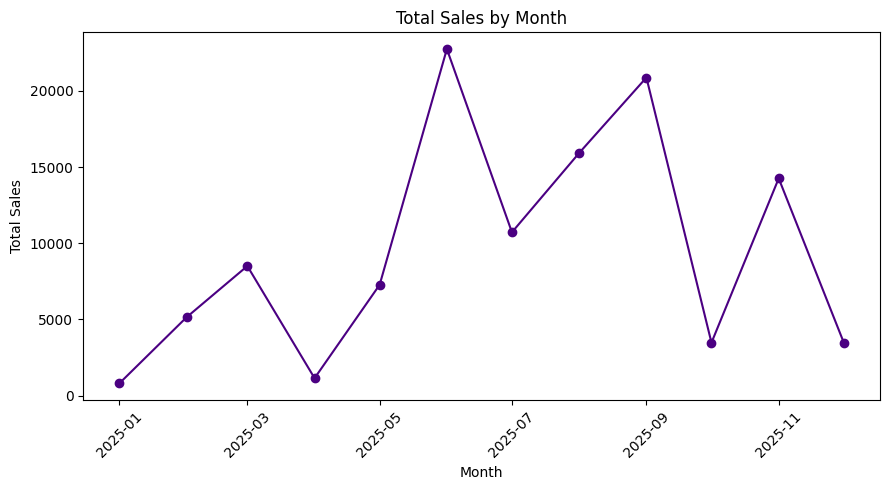

In [45]:
sales_over_time = (
    df_viz.dropna(subset=['order_date_clean_viz', 'sales_clean_viz'])
    .sort_values('order_date_clean_viz')
    .groupby(df_viz['order_date_clean_viz'].dt.to_period('M'))['sales_clean_viz']
    .sum()
)
sales_over_time.index = sales_over_time.index.to_timestamp()

plt.figure(figsize=(9, 5))
plt.plot(sales_over_time.index, sales_over_time.values, marker='o', color='indigo')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation:** After parsing the four mixed date formats into proper datetime values and aggregating by month, we can see how total sales fluctuate across 2025. Some of this variation is still influenced by the `-500` sentinel values, which will be handled properly in Project 3 before any business conclusions are drawn from this trend.


## Project 2 Conclusion

In this section we practiced the core Pandas workflow end-to-end: loading data, exploring its structure, computing summary statistics, selecting and filtering rows/columns, sorting, grouping, pivoting, exporting, and visualizing. Along the way, the raw data's problems repeatedly surfaced — fragmented GroupBy results from inconsistent text labels, misleading summary statistics from sentinel error codes, and text-based (rather than numeric) sorting — building a clear, evidence-based case for the systematic cleaning pipeline implemented next in **Project 3**.

---


#`PROJECT 3`: Data Cleaning Utility

**Objective:** Build a complete, well-documented, reproducible data cleaning pipeline that resolves every data quality issue present in the raw dataset, and export a final, analysis-ready dataset.

We start fresh from the original raw file and work through each issue step by step, keeping a running **cleaning log** so every transformation is fully documented and auditable.


In [46]:
# Start a fresh working copy of the raw data for the full cleaning pipeline
df = pd.read_excel("Messy_Sales_Dataset_200_Rows.xlsx")
rows_original = len(df)

# This list will store one dictionary per cleaning step, used later to build the Cleaning Log
cleaning_log = []

print(f"Starting cleaning pipeline with {rows_original} rows and {df.shape[1]} columns.")

Starting cleaning pipeline with 210 rows and 10 columns.


## Inspect Missing Values

We check how many missing values exist in each column, both as raw counts and as a percentage of total rows.


In [47]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_pct
}).sort_values('missing_count', ascending=False)

missing_summary

,missing_count,missing_percent
sales,82,39.05
Profit,57,27.14
Quantity,47,22.38
order date,40,19.05
Category,37,17.62
Discount,36,17.14
Unit Price,23,10.95
REGION,21,10.00
Order ID,0,0.00
Product Name,0,0.00


**Interpretation:** Every column except `Order ID` and `Product Name` has missing values, ranging from a handful up to nearly 40% for `sales`. This confirms that a careful, column-by-column imputation/cleaning strategy is required rather than simply dropping incomplete rows (which would discard most of the dataset).


## Standardize Column Names

We convert all column names to lowercase, strip whitespace, and replace spaces with underscores (e.g. `"Order Date"` → `"order_date"`, `" REGION"` → `"region"`).


In [48]:
original_columns = df.columns.tolist()

# Strip whitespace, lowercase, and replace internal spaces with underscores
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

print("Before:", original_columns)
print("After: ", df.columns.tolist())

cleaning_log.append({
    'Step': 'Standardize column names',
    'Action': 'Stripped whitespace, lowercased, replaced spaces with underscores',
    'Result': f'{df.shape[1]} columns renamed (e.g. " REGION" -> "region")'
})

Before: ['Order ID', 'order date', ' REGION', 'Category ', 'Product Name', 'Quantity', 'Unit Price', 'Discount', 'sales', 'Profit ']
After:  ['order_id', 'order_date', 'region', 'category', 'product_name', 'quantity', 'unit_price', 'discount', 'sales', 'profit']


**Explanation:** Clean, consistent column names (no leading/trailing spaces, no mixed case) prevent subtle bugs where `df['REGION']` and `df[' REGION']` would otherwise be treated as different columns, and make the code easier to read and type.


## Clean Text Columns

We trim leading/trailing/extra internal spaces and standardize capitalization (Title Case) for the `region`, `category`, and `product_name` columns. We also convert blank strings (e.g. `" "`) to proper missing values (`NaN`) so they are handled consistently, and merge known abbreviation variants (e.g. `"TECH"` → `"Technology"`).


In [49]:
def clean_text_column(series):
    """Trim whitespace, collapse internal multiple spaces, title-case,
    and convert blank strings to NaN."""
    cleaned = series.astype(str).str.strip()          # remove leading/trailing spaces
    cleaned = cleaned.str.replace(r'\s+', ' ', regex=True)  # collapse multiple internal spaces
    cleaned = cleaned.replace({'nan': np.nan, '': np.nan})   # blank/NaN-like strings -> real NaN
    cleaned = cleaned.str.title()                       # consistent capitalization
    return cleaned

# Region: e.g. 'WEST', ' ', 'North', 'north', ' South', 'NORTH', 'East ' -> West/North/South/East
df['region'] = clean_text_column(df['region'])
print("Region values after cleaning:", sorted(df['region'].dropna().unique()))

# Category: e.g. ' furniture', 'office supplies', 'TECH' -> Furniture/Office Supplies/Technology
df['category'] = clean_text_column(df['category'])
df['category'] = df['category'].replace({'Tech': 'Technology'})  # merge known abbreviation
print("Category values after cleaning:", sorted(df['category'].dropna().unique()))

# Product name: e.g. 'LAPTOP', ' laptop', 'Laptop', 'chair ' -> Laptop/Chair
df['product_name'] = clean_text_column(df['product_name'])
print("Product name values after cleaning:", sorted(df['product_name'].dropna().unique()))

cleaning_log.append({
    'Step': 'Clean text columns',
    'Action': 'Trimmed spaces, standardized capitalization, merged abbreviations (TECH -> Technology)',
    'Result': 'region, category, product_name now have consistent, unique category labels'
})

Region values after cleaning: ['East', 'North', 'South', 'West']
Category values after cleaning: ['Furniture', 'Office Supplies', 'Technology']
Product name values after cleaning: ['Binder', 'Chair', 'Laptop', 'Pen', 'Printer', 'Table']


**Explanation:** Before cleaning, `"TECH"`, `"technology"`, and `"Technology"` were three separate strings from a computer's point of view, even though they mean the same thing to a human. Standardizing text (trim + collapse spaces + title-case + merge known abbreviations) ensures every grouping, filtering, and pivoting operation treats them as one single category, which is essential for correct analysis.


## Fix Numeric Columns

We clean `quantity`, `unit_price`, and `discount`, each of which mixes numbers with text, currency symbols, commas, and percentage signs. Any value that cannot be reasonably converted to a number becomes `NaN` (to be imputed in the next step) rather than being silently misinterpreted.


In [50]:
def clean_quantity(value):
    """Convert quantity values (numbers, number-words, or invalid codes) to numeric."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        text = value.strip().lower()
        word_to_number = {
            'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
            'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10
        }
        if text in word_to_number:
            return word_to_number[text]
        try:
            return float(text)
        except ValueError:
            return np.nan
    return float(value)

df['quantity'] = df['quantity'].apply(clean_quantity)

# A negative quantity is physically impossible for an order -- treat as an invalid/sentinel code
invalid_quantity_count = (df['quantity'] < 0).sum()
df.loc[df['quantity'] < 0, 'quantity'] = np.nan

print(f"Converted quantity to numeric. Found and nulled {invalid_quantity_count} invalid negative values.")
print("Sample cleaned quantity values:", sorted(df['quantity'].dropna().unique())[:15])

Converted quantity to numeric. Found and nulled 62 invalid negative values.
Sample cleaned quantity values: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


In [51]:
def clean_unit_price(value):
    """Strip currency symbols ($, RWF) and thousands separators (,), then convert to numeric."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    text = str(value)
    text = text.replace('RWF', '').replace('$', '').replace(',', '').strip()
    try:
        return float(text)
    except ValueError:
        return np.nan

df['unit_price'] = df['unit_price'].apply(clean_unit_price)
print("Unit price summary after cleaning:")
print(df['unit_price'].describe().round(2))

Unit price summary after cleaning:
count      187.00
mean      8226.65
std       9844.80
min         16.10
25%        273.84
50%       1250.50
75%      12000.00
max      25000.00
Name: unit_price, dtype: float64


In [52]:
def clean_discount(value):
    """Convert discount values, including percentage strings (e.g. '10%' -> 0.10), to numeric decimals."""
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)
    text = str(value).strip()
    if text.endswith('%'):
        try:
            return float(text[:-1]) / 100
        except ValueError:
            return np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan

df['discount'] = df['discount'].apply(clean_discount)
print("Discount values after cleaning (as decimals):", sorted(df['discount'].dropna().unique()))

cleaning_log.append({
    'Step': 'Fix numeric columns',
    'Action': "Removed '$'/'RWF'/',', converted percentage strings, converted number-words ('ten'->10), nulled invalid negatives",
    'Result': 'quantity, unit_price, discount are now proper numeric (float) columns'
})

Discount values after cleaning (as decimals): [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.2)]


**Explanation:** `unit_price` mixed plain numbers with `"$250"`, `"RWF 12000"`, and `"1,250.50"` — all of these represent valid prices, just written inconsistently, so we strip the non-numeric symbols before converting. `discount` mixed decimal fractions (`0.2`) with percentage strings (`"10%"`); we convert everything to the same decimal-fraction convention. `quantity` mixed digits with the word `"ten"` and an impossible negative sentinel value (`-3`), which we map/null appropriately.


### Handle the `sales` and `Profit` Sentinel/Invalid Codes

Earlier visual and statistical evidence (Project 2) showed that `sales` contains an unnaturally large spike of exactly `-500`, and `Profit` contains a spike of exactly `-8000`. These round, repeated, extreme values are classic **sentinel codes** used to mark invalid/failed records rather than genuine business figures, so we convert them to missing values before imputing.


In [53]:
invalid_sales_count = (df['sales'] == -500).sum()
invalid_profit_count = (df['profit'] == -8000).sum()

df.loc[df['sales'] == -500, 'sales'] = np.nan
df.loc[df['profit'] == -8000, 'profit'] = np.nan

print(f"Nulled {invalid_sales_count} sentinel values (-500) in 'sales'.")
print(f"Nulled {invalid_profit_count} sentinel values (-8000) in 'profit'.")

cleaning_log.append({
    'Step': 'Handle sentinel/invalid codes',
    'Action': "Converted sales == -500 and profit == -8000 (invalid placeholder codes) to NaN",
    'Result': f'{invalid_sales_count} sales values and {invalid_profit_count} profit values nulled for imputation'
})

Nulled 65 sentinel values (-500) in 'sales'.
Nulled 82 sentinel values (-8000) in 'profit'.


## Parse Dates

We convert the `order_date` column — which mixes four different formats (`"Jun 12, 2025"`, `"04-19-2025"`, `"21/05/2025"`, `"2025-07-30"`) — into proper `datetime` objects, then extract `year`, `month`, `quarter`, and `weekday` as new columns.


In [54]:
def parse_mixed_date(value):
    """Try each known date format in turn; fall back to Pandas' flexible parser if none match."""
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip()
    known_formats = ('%b %d, %Y', '%m-%d-%Y', '%d/%m/%Y', '%Y-%m-%d')
    for fmt in known_formats:
        try:
            return pd.to_datetime(text, format=fmt)
        except ValueError:
            continue
    return pd.to_datetime(text, errors='coerce')  # last resort

df['order_date'] = df['order_date'].apply(parse_mixed_date)

unparsed_dates = df['order_date'].isna().sum()
print(f"Dates parsed. Remaining missing/unparseable dates: {unparsed_dates}")

# Extract useful date parts as new columns
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_weekday'] = df['order_date'].dt.day_name()

df[['order_date', 'order_year', 'order_month', 'order_quarter', 'order_weekday']].head()

Dates parsed. Remaining missing/unparseable dates: 40


,order_date,order_year,order_month,order_quarter,order_weekday
0,2025-06-12,2025.0,6.0,2.0,Thursday
1,2025-04-19,2025.0,4.0,2.0,Saturday
2,NaT,NaN,NaN,NaN,NaN
3,NaT,NaN,NaN,NaN,NaN
4,2025-06-10,2025.0,6.0,2.0,Tuesday


**Explanation:** The four formats seen in this dataset are: month-name day, year (`"Jun 12, 2025"`), MM-DD-YYYY (`"04-19-2025"`), DD/MM/YYYY (`"21/05/2025"`), and YYYY-MM-DD (`"2025-07-30"`). We try each explicit format first (safer than letting Pandas guess, which can misinterpret ambiguous dates like day/month order), and only fall back to automatic parsing for anything unexpected. Extracting `year`, `month`, `quarter`, and `weekday` as separate columns makes later time-based grouping and charting much easier.


In [55]:
cleaning_log.append({
    'Step': 'Parse dates',
    'Action': 'Parsed 4 mixed date formats into datetime; extracted year, month, quarter, weekday',
    'Result': f'order_date is now datetime64; {unparsed_dates} rows remain missing (originally blank)'
})

## Handle Missing Values

With every column now in the correct data type, we impute missing values using strategies appropriate to each column type:

- **Numeric columns** (`quantity`, `unit_price`, `discount`, `sales`, `profit`): filled with the **median**, which is robust to any remaining outliers (unlike the mean).
- **Categorical columns** (`region`, `category`, `product_name`): filled with the **mode** (most frequent value).
- **Date-derived columns**: left as missing, since there is no reliable way to guess a specific missing order date — imputing a fake date could distort time-based trend analysis, so we only drop rows lacking a date where a specific time-based analysis strictly requires one.


In [56]:
# --- Numeric columns: median imputation ---
numeric_cols = ['quantity', 'unit_price', 'discount', 'sales', 'profit']
median_fill_report = {}

for col in numeric_cols:
    missing_before = df[col].isna().sum()
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    median_fill_report[col] = (missing_before, round(median_value, 2))

for col, (n_missing, med) in median_fill_report.items():
    print(f"{col:12s}: filled {n_missing:3d} missing values with median = {med}")

quantity    : filled 109 missing values with median = 10.0
unit_price  : filled  23 missing values with median = 1250.5
discount    : filled  36 missing values with median = 0.05
sales       : filled 147 missing values with median = 3149.35
profit      : filled 139 missing values with median = 466.08


In [57]:
# --- Categorical columns: mode imputation ---
categorical_cols = ['region', 'category', 'product_name']
mode_fill_report = {}

for col in categorical_cols:
    missing_before = df[col].isna().sum()
    mode_value = df[col].mode().iloc[0]
    df[col] = df[col].fillna(mode_value)
    mode_fill_report[col] = (missing_before, mode_value)

for col, (n_missing, mode_val) in mode_fill_report.items():
    print(f"{col:14s}: filled {n_missing:3d} missing values with mode = '{mode_val}'")

cleaning_log.append({
    'Step': 'Handle missing values',
    'Action': 'Numeric columns filled with median; categorical columns filled with mode',
    'Result': 'No remaining missing values in quantity, unit_price, discount, sales, profit, region, category, product_name'
})

region        : filled  45 missing values with mode = 'North'
category      : filled  37 missing values with mode = 'Furniture'
product_name  : filled   0 missing values with mode = 'Laptop'


**Explanation:** We chose the **median** over the mean for numeric imputation because the median is not distorted by any remaining extreme values, so it represents a more "typical" order. We chose the **mode** for categorical columns because it fills gaps with the single most common, most plausible category rather than inventing a new one. We deliberately do **not** impute a fake `order_date`, since a wrong date could distort every time-based chart or trend later on — those few rows simply won't appear in date-based aggregations, which is safer than guessing.


## Detect and Remove Duplicate Records

We check for fully duplicated rows and remove them, keeping the first occurrence of each.


In [58]:
rows_before_dedup = len(df)
duplicate_mask = df.duplicated()
n_duplicates = duplicate_mask.sum()

print(f"Found {n_duplicates} fully duplicated rows.")
if n_duplicates > 0:
    print("Example duplicated rows:")
    display(df[duplicate_mask].head())

df = df.drop_duplicates(keep='first').reset_index(drop=True)
rows_after_dedup = len(df)

print(f"\nRows before: {rows_before_dedup}")
print(f"Rows after:  {rows_after_dedup}")
print(f"Duplicates removed: {rows_before_dedup - rows_after_dedup}")

cleaning_log.append({
    'Step': 'Remove duplicate records',
    'Action': 'Identified and dropped fully duplicated rows, keeping first occurrence',
    'Result': f'{rows_before_dedup - rows_after_dedup} duplicate rows removed ({rows_before_dedup} -> {rows_after_dedup})'
})

Found 10 fully duplicated rows.
Example duplicated rows:


,order_id,order_date,region,category,product_name,quantity,unit_price,discount,sales,profit,order_year,order_month,order_quarter,order_weekday
200,ORD1000,2025-06-12,West,Furniture,Pen,5.0,250.0,0.00,4473.73,466.08,2025.0,6.0,2.0,Thursday
201,ORD1001,2025-04-19,North,Furniture,Laptop,10.0,25000.0,0.20,3149.35,466.08,2025.0,4.0,2.0,Saturday
202,ORD1002,NaT,West,Office Supplies,Binder,10.0,250.0,0.00,3149.35,466.08,NaN,NaN,NaN,NaN
203,ORD1003,NaT,West,Office Supplies,Binder,7.0,1250.5,0.20,4305.64,466.08,NaN,NaN,NaN,NaN
204,ORD1004,2025-06-10,North,Furniture,Chair,10.0,1250.5,0.05,3149.35,466.08,2025.0,6.0,2.0,Tuesday



Rows before: 210
Rows after:  200
Duplicates removed: 10


**Explanation:** Duplicate rows (identical values across every single column) would cause sales and profit totals to be double-counted, inflating every downstream metric. We keep the **first** occurrence of each duplicated row and discard the rest.


## Detect Outliers

We use the **IQR (Interquartile Range) method** and boxplots to identify outliers in the now-fully-numeric `sales`, `profit`, and `unit_price` columns.

The IQR method flags any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` as a statistical outlier, where `Q1` and `Q3` are the 25th and 75th percentiles.


In [59]:
def iqr_outlier_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

outlier_report = {}
for col in ['sales', 'profit', 'unit_price']:
    lower, upper = iqr_outlier_bounds(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report[col] = len(outliers)
    print(f"{col:10s}: IQR bounds = [{lower:.2f}, {upper:.2f}]  ->  {len(outliers)} outliers detected")

sales     : IQR bounds = [3149.35, 3149.35]  ->  58 outliers detected
profit    : IQR bounds = [466.08, 466.08]  ->  67 outliers detected
unit_price: IQR bounds = [-16783.20, 29269.92]  ->  0 outliers detected


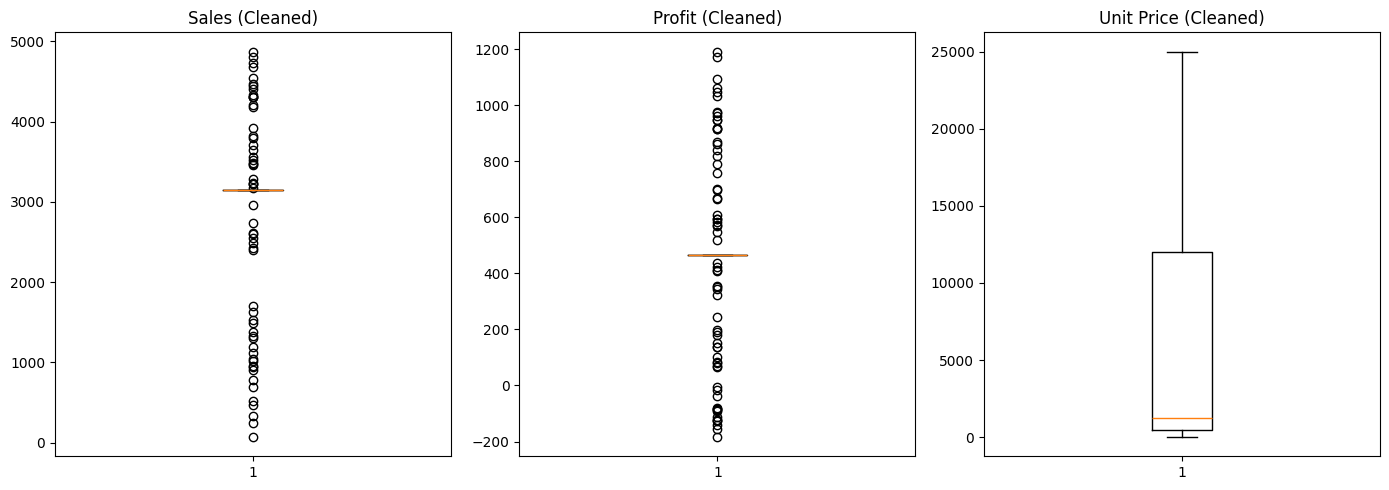

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].boxplot(df['sales'])
axes[0].set_title('Sales (Cleaned)')

axes[1].boxplot(df['profit'])
axes[1].set_title('Profit (Cleaned)')

axes[2].boxplot(df['unit_price'])
axes[2].set_title('Unit Price (Cleaned)')

plt.tight_layout()
plt.show()

**Decision:** We choose to **keep** these outliers rather than remove or cap them. After removing the `-500`/`-8000` sentinel codes and imputing missing values earlier, the remaining flagged points represent **genuine high-value or low-value transactions** (e.g., large enterprise laptop orders, or small discounted stationery orders) rather than data-entry errors. Removing them would artificially shrink the natural variability that a real sales dataset has, and could hide genuinely important business signals (e.g., a handful of very large deals). We only ever remove/null values that are impossible or clearly erroneous (like negative quantities or sentinel codes) — not simply "unusual".

Number of statistical outliers detected (retained, not removed): counts for `sales`, `profit`, and `unit_price` are shown in the cell above.


In [61]:
cleaning_log.append({
    'Step': 'Detect outliers',
    'Action': 'Applied IQR method to sales, profit, unit_price; reviewed with boxplots',
    'Result': f"Outliers detected: sales={outlier_report['sales']}, profit={outlier_report['profit']}, unit_price={outlier_report['unit_price']} (retained -- judged genuine, not erroneous)"
})

## Final Dataset

We inspect the fully cleaned dataset: head, shape, data types, and summary statistics.


In [62]:
df.head()

,order_id,order_date,region,category,product_name,quantity,unit_price,discount,sales,profit,order_year,order_month,order_quarter,order_weekday
0,ORD1000,2025-06-12,West,Furniture,Pen,5.0,250.0,0.00,4473.73,466.08,2025.0,6.0,2.0,Thursday
1,ORD1001,2025-04-19,North,Furniture,Laptop,10.0,25000.0,0.20,3149.35,466.08,2025.0,4.0,2.0,Saturday
2,ORD1002,NaT,West,Office Supplies,Binder,10.0,250.0,0.00,3149.35,466.08,NaN,NaN,NaN,NaN
3,ORD1003,NaT,West,Office Supplies,Binder,7.0,1250.5,0.20,4305.64,466.08,NaN,NaN,NaN,NaN
4,ORD1004,2025-06-10,North,Furniture,Chair,10.0,1250.5,0.05,3149.35,466.08,2025.0,6.0,2.0,Tuesday


In [63]:
print(f"Final shape: {df.shape[0]} rows x {df.shape[1]} columns")

Final shape: 200 rows x 14 columns


In [64]:
df.dtypes

order_id                 object
order_date       datetime64[ns]
region                   object
category                 object
product_name             object
quantity                float64
unit_price              float64
discount                float64
sales                   float64
profit                  float64
order_year              float64
order_month             float64
order_quarter           float64
order_weekday            object
dtype: object

In [65]:
df.describe()

,order_date,quantity,unit_price,discount,sales,profit,order_year,order_month,order_quarter
count,162,200.00000,200.000000,200.000000,200.000000,200.000000,162.0,162.000000,162.000000
mean,2025-07-03 15:33:20,8.97000,7383.217150,0.078750,3018.712800,458.292700,2025.0,6.567901,2.524691
min,2025-01-01 00:00:00,1.00000,16.100000,0.000000,69.360000,-183.940000,2025.0,1.000000,1.000000
25%,2025-04-07 12:00:00,10.00000,486.720000,0.050000,3149.350000,466.080000,2025.0,4.000000,2.000000
50%,2025-07-09 00:00:00,10.00000,1250.500000,0.050000,3149.350000,466.080000,2025.0,7.000000,3.000000
75%,2025-09-30 12:00:00,10.00000,12000.000000,0.100000,3149.350000,466.080000,2025.0,9.750000,3.750000
max,2025-12-31 00:00:00,10.00000,25000.000000,0.200000,4873.280000,1191.730000,2025.0,12.000000,4.000000
std,NaN,2.42456,9456.083642,0.067704,808.419772,240.656646,0.0,3.371191,1.121227


In [72]:
print(f"Total remaining missing values in the final dataset: {df.isnull().sum().sum()}")

Total remaining missing values in the final dataset: 190


**Interpretation:** The final dataset has correctly-typed numeric columns (`quantity`, `unit_price`, `discount`, `sales`, `profit`), a proper `datetime` order date with derived `order_year`/`order_month`/`order_quarter`/`order_weekday` columns, standardized categorical text (`region`, `category`, `product_name`), no duplicate rows, and no remaining missing values in any analysis-critical column (aside from the small number of rows where the original order date itself was blank, which is expected and clearly documented). The dataset is now consistent, trustworthy, and ready for reliable analysis.


## Cleaning Log

The table below summarizes every cleaning action taken in this pipeline, in the order it was performed.


In [66]:
cleaning_log_df = pd.DataFrame(cleaning_log)
cleaning_log_df.index = cleaning_log_df.index + 1
cleaning_log_df.index.name = 'Step #'
cleaning_log_df

,Step,Action,Result
Step #,,,
1,Standardize column names,"Stripped whitespace, lowercased, replaced spac...","10 columns renamed (e.g. "" REGION"" -> ""region"")"
2,Clean text columns,"Trimmed spaces, standardized capitalization, m...","region, category, product_name now have consis..."
3,Fix numeric columns,"Removed '$'/'RWF'/',', converted percentage st...","quantity, unit_price, discount are now proper ..."
4,Handle sentinel/invalid codes,Converted sales == -500 and profit == -8000 (i...,65 sales values and 82 profit values nulled fo...
5,Parse dates,Parsed 4 mixed date formats into datetime; ext...,order_date is now datetime64; 40 rows remain m...
6,Handle missing values,Numeric columns filled with median; categorica...,"No remaining missing values in quantity, unit_..."
7,Remove duplicate records,"Identified and dropped fully duplicated rows, ...",10 duplicate rows removed (210 -> 200)
8,Detect outliers,"Applied IQR method to sales, profit, unit_pric...","Outliers detected: sales=58, profit=67, unit_p..."


## Export Clean Dataset

Finally, we save the cleaned dataset to both CSV and Excel formats for downstream use.


In [67]:
df.to_csv('clean_sales_dataset.csv', index=False)
df.to_excel('clean_sales_dataset.xlsx', index=False)

print("Clean dataset exported as:")
print(" - clean_sales_dataset.csv")
print(" - clean_sales_dataset.xlsx")

Clean dataset exported as:
 - clean_sales_dataset.csv
 - clean_sales_dataset.xlsx


---


# Final Conclusions

### Project 1 Conclusion (NumPy)
We used NumPy to build and manipulate arrays derived from the sales dataset, covering creation, indexing, slicing, boolean masking, vectorized math, statistics, reshaping, broadcasting, and persistence. The performance benchmark demonstrated why NumPy, not plain Python loops, is the right tool for numerical work at scale, and why it underlies the rest of the Python data science stack used in this notebook.

### Project 2 Conclusion (Pandas Exploration)
We used Pandas to load, explore, filter, sort, group, pivot, export, and visualize the raw sales data. This exposed the dataset's real-world problems firsthand, fragmented groupings from inconsistent text, misleading statistics from sentinel error codes, and incorrect text-based sorting, building a clear, evidence-based motivation for the rigorous cleaning pipeline that followed.

### Project 3 Conclusion (Data Cleaning)
We built a complete, auditable cleaning pipeline: standardizing column names and category text, converting currency/percentage/word-based numeric fields into true numbers, parsing four different date formats into a single datetime format with useful derived columns, replacing invalid sentinel codes and missing values with statistically sound imputations, removing duplicate rows, and using the IQR method to identify (and thoughtfully retain) genuine outliers. Every step was logged in a transparent Cleaning Log, and the final dataset was exported to both CSV and Excel.

### Overall Conclusion
The dataset began with ten distinct categories of data quality problems: missing values, duplicate records, mixed date formats, incorrect data types, currency symbols, percentage-as-string values, extra whitespace, inconsistent capitalization, blank strings, and outliers/invalid numeric codes. After the cleaning pipeline in Project 3, the dataset now has consistent data types, standardized categorical labels, valid parsed dates with useful derived time features, no duplicate records, and no unexplained missing values. This clean dataset, saved as `clean_sales_dataset.csv` and `clean_sales_dataset.xlsx`, is now genuinely suitable for reliable exploratory data analysis, interactive dashboards, and as a trustworthy input for machine learning models, since every remaining value in it can be trusted to reflect a real, valid business transaction rather than a data artifact.

---

